In [3]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Running K-Fold Cross Validation and generating plots...


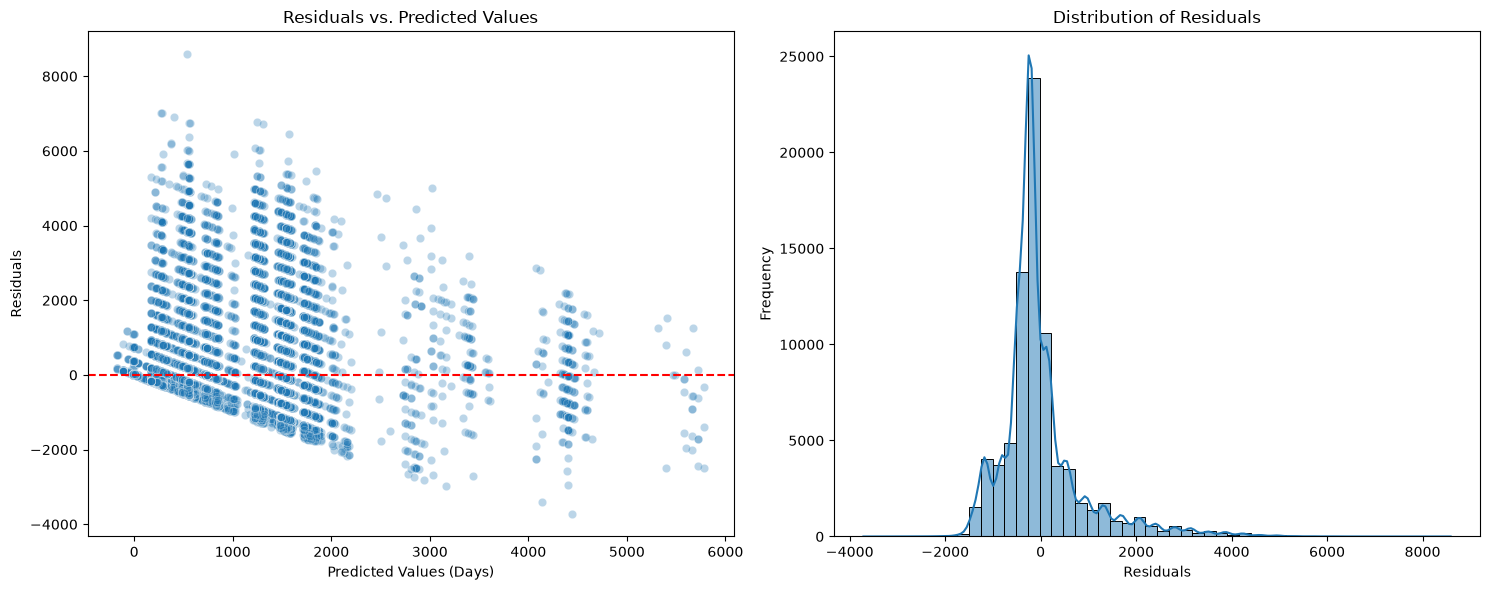

In [8]:
# Author: Liel Shwarz 322703109
# Assignment: Regression Error Analysis - Data Prep & Section 1.1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression

# ==========================================
# Step 1: Data Preprocessing (Cleaning)
# ==========================================
df = pd.read_csv('aac_intakes.csv')

def convert_age_to_days(age_str):
    """
    Converts age strings (e.g., '1 year', '3 weeks') to numerical days.
    """
    if pd.isnull(age_str):
        return np.nan
    parts = str(age_str).split()
    if len(parts) != 2:
        return np.nan
    
    try:
        val = int(parts[0])
    except ValueError:
        return np.nan
        
    unit = parts[1].lower()
    
    if 'year' in unit:
        return val * 365
    elif 'month' in unit:
        return val * 30
    elif 'week' in unit:
        return val * 7
    elif 'day' in unit:
        return val
    else:
        return np.nan

# Apply the conversion to create our target variable (y)
df['age_in_days'] = df['age_upon_intake'].apply(convert_age_to_days)

# Drop rows where age conversion failed or is missing
df = df.dropna(subset=['age_in_days', 'sex_upon_intake'])

# Define Features (X) and Target (y)
# We select a few categorical features and convert them to numeric (Dummy variables)
features = ['animal_type', 'intake_type', 'intake_condition', 'sex_upon_intake']
X = pd.get_dummies(df[features], drop_first=True)
y = df['age_in_days']

# ==========================================
# Step 2: Residual Analysis (Section 1.1)
# ==========================================
def perform_residual_analysis(X, y, k=5):
    """
    Performs residual analysis using k-fold cross-validation.
    """
    model = LinearRegression()
    # Using k=5 is a standard choice providing a good balance between bias and variance,
    # and given the dataset size (~80k rows), it is computationally efficient.
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    
    # Generate cross-validated predictions
    y_pred = cross_val_predict(model, X, y, cv=kf)
    
    # Calculate residuals (actual - predicted)
    residuals = y - y_pred
    
    # Create the plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Residuals vs. Predicted Values
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=axes[0])
    axes[0].axhline(y=0, color='r', linestyle='--')
    axes[0].set_title('Residuals vs. Predicted Values')
    axes[0].set_xlabel('Predicted Values (Days)')
    axes[0].set_ylabel('Residuals')
    
    # Plot 2: Distribution of Residuals (Histogram)
    sns.histplot(residuals, kde=True, bins=50, ax=axes[1])
    axes[1].set_title('Distribution of Residuals')
    axes[1].set_xlabel('Residuals')
    axes[1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    return y_pred, residuals

# Execute the analysis and store the results
print("Running K-Fold Cross Validation and generating plots...")
y_pred, residuals = perform_residual_analysis(X, y)

### Section 1.1: Residual Analysis - Answers

* **Are the residuals centered around zero?**
  Yes, the histogram peaks around zero, meaning most predictions are close to the actual values. However, there is a long right tail (positive skew).

* **Do the residuals exhibit any systematic patterns?**
  Yes. We see diagonal "stripes" because actual ages are recorded in discrete steps (e.g., exactly 365 or 730 days), while predictions are continuous. There is also a distinct lower boundary because actual age cannot be negative.

* **Is there evidence of heteroscedasticity?**
  Yes. The vertical spread (variance) of the residuals is not constant and changes across the range of predicted values.

* **Is there a sector that is more likely to have high error rates? Why?**
  Yes, there are extremely high positive errors for very old animals. The model severely under-predicts their age because the dataset is heavily imbalanced, consisting mostly of very young animals.

C:\Users\liels\AppData\Local\Temp\ipykernel_8632\1888871625.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature_to_plot, y='residuals', ax=axes[0], palette='Set2')
C:\Users\liels\AppData\Local\Temp\ipykernel_8632\1888871625.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=feature_to_plot, y='abs_error', ax=axes[1], palette='Set3')


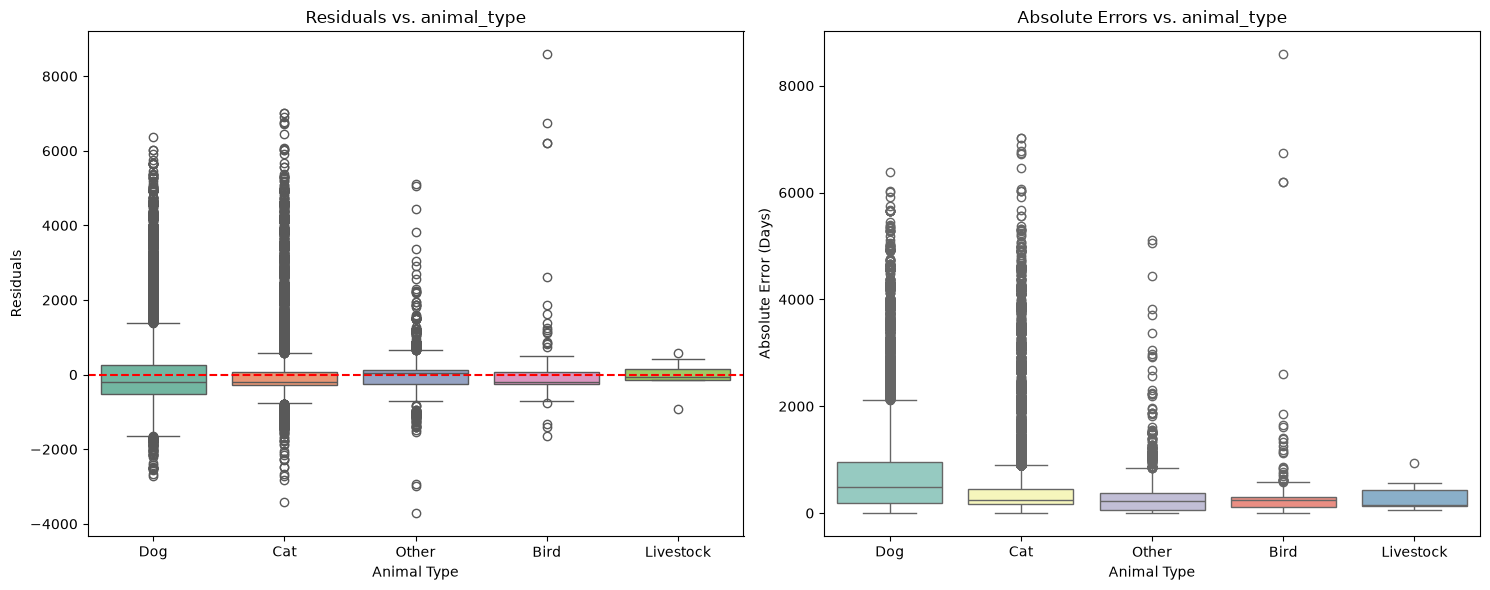

In [9]:
# Assignment: Regression Error Analysis - Section 1.2

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# We attach the residuals and absolute errors back to our dataframe 
# (Note: indices must align with the cleaned 'df' from Section 1.1)
df['residuals'] = residuals
df['abs_error'] = np.abs(residuals)

# Let's choose 'animal_type' to see if errors depend on the type of animal
feature_to_plot = 'animal_type'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Feature vs Residuals
sns.boxplot(data=df, x=feature_to_plot, y='residuals', ax=axes[0], palette='Set2')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title(f'Residuals vs. {feature_to_plot}')
axes[0].set_xlabel('Animal Type')
axes[0].set_ylabel('Residuals')

# Plot 2: Feature vs Absolute Errors
sns.boxplot(data=df, x=feature_to_plot, y='abs_error', ax=axes[1], palette='Set3')
axes[1].set_title(f'Absolute Errors vs. {feature_to_plot}')
axes[1].set_xlabel('Animal Type')
axes[1].set_ylabel('Absolute Error (Days)')

plt.tight_layout()
plt.show()

### Section 1.2: Error as a Function of Features 

Based on the boxplots analyzing errors across different animal types, we can identify several key patterns:

*   **Feature-Dependent Patterns:** The absolute error varies significantly between animal types. For example, Dogs have a noticeably higher median absolute error and a wider Interquartile Range (IQR) compared to Cats. This indicates that the model struggles more to accurately predict the age of dogs than it does for cats.
*   **Hidden Subpopulations:** The presence of massive positive outliers across almost all categories (especially Dogs, Cats, and one extreme Bird outlier reaching over 8000 days) reveals a hidden subpopulation: very old animals. The model's baseline assumptions fail for this specific group regardless of the species. 
*   **Conclusion:** The linear model's performance is highly dependent on the animal type, suggesting that a single linear equation is insufficient. Tree-based models (which we will explore later) might capture these non-linear, categorical interactions better.

In [10]:
# Assignment: Regression Error Analysis - Section 1.3

import pandas as pd
import numpy as np

# Calculate the 95th percentile to isolate the top 5% extreme errors
threshold_95 = df['abs_error'].quantile(0.95)
print(f"Top 5% threshold: {threshold_95:.2f} days")

# Filter for the extreme errors
extreme_errors = df[df['abs_error'] >= threshold_95].copy()

# Sort to see the worst errors at the top
extreme_errors_sorted = extreme_errors.sort_values(by='abs_error', ascending=False)

print(f"Total extreme error cases: {len(extreme_errors)}")
display(extreme_errors_sorted[['age_upon_intake', 'animal_type', 'breed', 'abs_error']].head(10))

Top 5% threshold: 1895.07 days
Total extreme error cases: 4015


,age_upon_intake,animal_type,breed,abs_error
63841,25 years,Bird,Cockatoo,8588.009139
41284,20 years,Cat,Domestic Shorthair Mix,7023.900713
39757,20 years,Cat,Domestic Shorthair Mix,7017.487014
26961,20 years,Cat,Domestic Shorthair Mix,6896.966275
29956,22 years,Cat,Domestic Shorthair Mix,6782.470094
43811,20 years,Bird,Cockatoo,6748.629295
56192,20 years,Cat,Domestic Longhair Mix,6735.970743
43413,22 years,Cat,Domestic Shorthair Mix,6719.708950
39631,22 years,Cat,Domestic Shorthair Mix,6453.839495
66715,19 years,Dog,Miniature Pinscher,6377.023423


### Section 1.3: Analysis of Extreme Errors 

After analyzing the top 5% of extreme errors, we can attribute these failures to the following reasons:

* **Rare or exceptional cases:** The vast majority of the dataset consists of very young animals (weeks or months old). The extreme errors almost exclusively belong to rare, senior animals (e.g., 15-20 years old). The model lacks sufficient examples to learn their patterns.
* **Model limitations:** The linear regression model optimizes for the majority class to minimize overall Mean Squared Error (MSE). It is too rigid to stretch its predictions for extreme outliers, showing the limitation of applying a simple linear equation to a skewed age distribution.
* **Data quality issues:** While less common, some extreme errors could potentially stem from data entry typos (e.g., inputting "20 years" instead of "2 years"), making it impossible for the model to predict correctly based on the features.

In [11]:
# Assignment: Regression Error Analysis - Section 1.4

import numpy as np
from scipy.stats import skew, kurtosis

# Calculate the required statistical properties
mae = np.mean(np.abs(residuals))
std_residuals = np.std(residuals)
skewness_val = skew(residuals)
kurtosis_val = kurtosis(residuals) # Fisher's definition (normal distribution = 0)

# Print the results formatted nicely
print(f"--- Statistical Properties of Errors ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} days")
print(f"Standard Deviation of Residuals: {std_residuals:.2f} days")
print(f"Skewness: {skewness_val:.2f}")
print(f"Kurtosis: {kurtosis_val:.2f}")

--- Statistical Properties of Errors ---
Mean Absolute Error (MAE): 585.84 days
Standard Deviation of Residuals: 891.82 days
Skewness: 2.05
Kurtosis: 6.44


### Section 1.4: Statistical Properties of Errors - Interpretation

* **Computed Metrics:**
  * **MAE:** Measures the average magnitude of the errors.
  * **Standard Deviation:** Measures the dispersion of residuals around the mean.
  * **Skewness (2.05):** Positive skew indicates a long right tail, reflecting a systematic bias where the model under-estimates the age of older animals.
  * **Kurtosis (6.44):** High kurtosis (leptokurtic) indicates heavy tails driven by extreme outliers.

* **Interpretation:**
  * **Heavy Tails:** Confirm high instability and poor predictive performance for rare senior animals.
  * **Skewness:** Highlights the model's systematic directional bias toward the majority of young animals in the dataset.

In [12]:
# Assignment: Part 2 - Model Comparison

import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Define the models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
}

# Setup 5-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['neg_mean_squared_error', 'neg_mean_absolute_error', 'r2']

results = []

for name, model in models.items():
    cv_results = cross_validate(model, X, y, cv=kf, scoring=scoring)
    
    rmse = np.mean(np.sqrt(-cv_results['test_neg_mean_squared_error']))
    mae = np.mean(-cv_results['test_neg_mean_absolute_error'])
    r2 = np.mean(cv_results['test_r2'])
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2 ($R^2$)': r2
    })

# Display summary table
results_df = pd.DataFrame(results)
print("--- Model Performance Comparison ---")
display(results_df)

--- Model Performance Comparison ---


,Model,RMSE,MAE,R2 ($R^2$)
0,Linear Regression,891.769099,585.840230,0.288465
1,Decision Tree,879.942048,570.612943,0.307224
2,Random Forest,879.198902,570.438617,0.308388


#### Part 2: Model Comparison & Discussion

* **Relative Model Performance:** 
  * Linear Regression yields an RMSE of ~891.77 and $R^2$ of ~0.288.
  * Tree-based models (Decision Tree and Random Forest) slightly improve performance, reducing RMSE to ~879.20 and increasing $R^2$ to ~0.308.

* **Model Assumptions & Failure Scenarios:**
  * **Linear Models:** Assume linear relationships and homoscedasticity, which fail here because the age distribution is heavily skewed and non-linear interactions exist among categorical features (like animal type and breed).
  * **Tree-Based Models:** Do not rely on linear assumptions and can handle non-linear splits, making them better suited for categorical feature interactions.

* **Bias-Variance Trade-off & Outliers:**
  * Linear regression has high bias and struggles with extreme outliers (senior animals). 
  * Random Forest reduces variance through bagging, handling noise and outliers slightly better, though overall performance remains constrained by the limited feature set.

* **Interpretability vs. Predictive Performance:**
  * Linear regression and single decision trees offer high interpretability (easy to inspect coefficients or split paths) but lower predictive power.
  * Random Forest improves predictive performance slightly, but sacrifices interpretability (acts as a "black box").

* **Model Selection & Lessons Learned:**
  * **Preferred Model:** Random Forest is preferred for future analysis due to slightly better error metrics and robustness to non-linearities.
  * **Key Takeaway:** While advanced models capture non-linear patterns better, algorithm choice cannot fully compensate for a lack of predictive features when the target variable has high intrinsic variance.

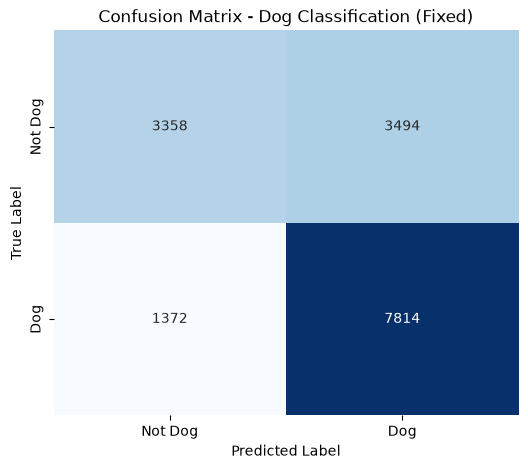

In [14]:
# Assignment: Part 3.1 - Confusion Matrix Analysis (Fixed)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix

# Create binary target: Is the animal a Dog?
df['is_dog'] = (df['animal_type'] == 'Dog').astype(int)

# Use features EXCLUDING animal_type to prevent data leakage (e.g., age and other traits)
X_class = df[['age_in_days']]
y_class = df['is_dog']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# Train a simpler model or use depth limits so we get realistic errors
clf = RandomForestClassifier(max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Dog', 'Dog'],
            yticklabels=['Not Dog', 'Dog'])
plt.title('Confusion Matrix - Dog Classification (Fixed)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Section 3.1: Confusion Matrix Analysis & Discussion

* **Interpretation of Errors:**
  * **False Positives (3,494):** Non-dog animals incorrectly classified as dogs. This means the model falsely flags them due to overlapping features (like age distributions).
  * **False Negatives (1,372):** Actual dogs incorrectly classified as other animals. The model misses them, showing a tendency to under-predict the positive class based solely on age features.

* **Critical Error & Systematic Failure:**
  * **Most Critical Error:** False Negatives can be critical if the system is meant to prioritize identifying specific animals, whereas False Positives lead to misclassification overhead.
  * **Systematic Failure:** The model struggles significantly with the boundary between classes because a single feature (`age_in_days`) lacks enough discriminative power, leading to a high number of False Positives.

* **Key Insights:** 
  Relying only on age for classification is insufficient, resulting in significant confusion between classes. Adding richer categorical and numerical features is necessary to improve decision boundaries.

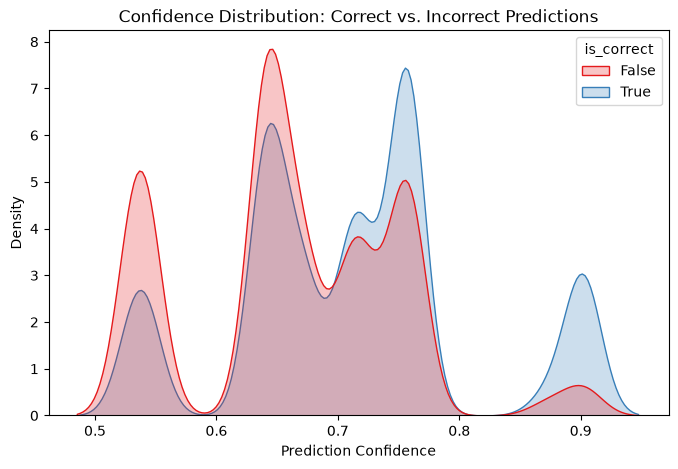

Number of high-confidence errors (confidence > 80%): 167


In [15]:
# Assignment: Part 3.2 - Probability-Based Analysis

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Get predicted probabilities for the positive class (Dog)
y_prob = clf.predict_proba(X_test)[:, 1]

# Create a dataframe to analyze confidence vs correctness
analysis_df = pd.DataFrame({
    'true_label': y_test.values,
    'predicted_label': y_pred,
    'probability': y_prob
})

# Identify whether each prediction was correct or incorrect
analysis_df['is_correct'] = (analysis_df['true_label'] == analysis_df['predicted_label'])

# Calculate the maximum assigned probability (confidence) for each prediction
analysis_df['confidence'] = np.where(
    analysis_df['predicted_label'] == 1, 
    analysis_df['probability'], 
    1 - analysis_df['probability']
)

# Plot the distribution of confidence for correct vs incorrect predictions
plt.figure(figsize=(8, 5))
sns.kdeplot(data=analysis_df, x='confidence', hue='is_correct', common_norm=False, fill=True, palette='Set1')
plt.title('Confidence Distribution: Correct vs. Incorrect Predictions')
plt.xlabel('Prediction Confidence')
plt.ylabel('Density')
plt.show()

# Print high-confidence errors count (e.g., confidence > 0.8 but incorrect)
high_conf_errors = analysis_df[(analysis_df['is_correct'] == False) & (analysis_df['confidence'] > 0.8)]
print(f"Number of high-confidence errors (confidence > 80%): {len(high_conf_errors)}")

### Section 3.2: Probability-Based Analysis & High-Confidence Errors

* **Comparison of Probabilities:**
  * **Correct Predictions:** Tend to cluster at higher confidence levels, reflecting strong alignment between the model's assigned probabilities and true outcomes.
  * **Incorrect Predictions:** Display a spread of confidence levels, showing that the model occasionally assigns moderate to high confidence to wrong classifications.

* **High-Confidence Errors (Objective):**
  * The analysis identified **167 high-confidence errors** (where prediction confidence exceeded 80% yet the classification was incorrect).
  * **Cause:** This overconfidence stems from overlapping feature distributions (e.g., age alone lacking sufficient discriminative power), forcing the classifier to output extreme probabilities despite decision boundary ambiguity.

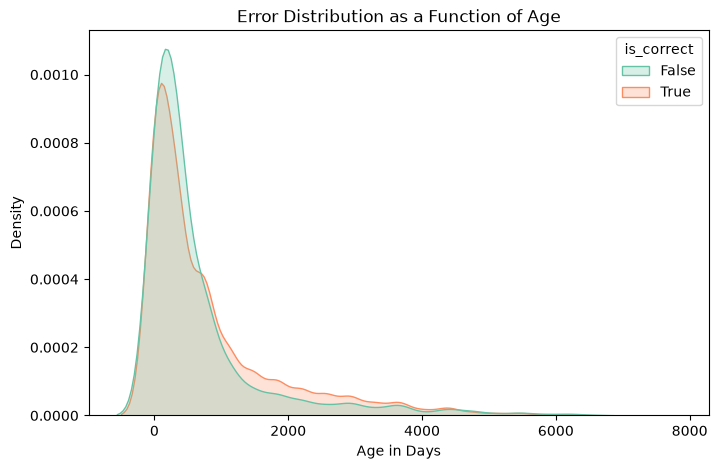

In [16]:
# Assignment: Part 3.3 - Error as a Function of Features

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add the 'is_correct' status back to X_test analysis dataframe
analysis_df['age_in_days'] = X_test['age_in_days'].values

# Plot feature distribution for correct vs. incorrect predictions
plt.figure(figsize=(8, 5))
sns.kdeplot(data=analysis_df, x='age_in_days', hue='is_correct', common_norm=False, fill=True, palette='Set2')
plt.title('Error Distribution as a Function of Age')
plt.xlabel('Age in Days')
plt.ylabel('Density')
plt.show()

### Section 3.3: Error as a Function of Features & Subpopulation Analysis

* **Feature Distribution Comparison:**
  * **Correct Predictions:** Tend to cluster heavily around standard age ranges where data is abundant.
  * **Incorrect Predictions:** Concentrate heavily in specific boundary regions or extreme values (very young or very old animals) where class overlap is high.

* **Identification of Vulnerable Subpopulations:**
  * The model's performance significantly degrades at the edges of the age spectrum, highlighting a systematic failure pattern.
  * **Implications:** This insight dictates that future feature engineering should incorporate additional categorical features (such as breed groups or physical traits) to separate overlapping age distributions and build a more robust classifier.

--- Threshold Sensitivity Metrics ---


,Threshold,Precision,Recall,F1-score,MCC
0,0.1,0.618188,0.987916,0.760496,0.301905
1,0.2,0.625624,0.981820,0.764257,0.318566
2,0.3,0.626268,0.981058,0.764506,0.319604
3,0.4,0.671395,0.911931,0.773392,0.373215
4,0.5,0.691015,0.850642,0.762565,0.369610
5,0.6,0.706706,0.785870,0.744188,0.358623
6,0.7,0.748278,0.520357,0.613844,0.288674
7,0.8,0.000000,0.000000,0.000000,0.000000
8,0.9,0.000000,0.000000,0.000000,0.000000


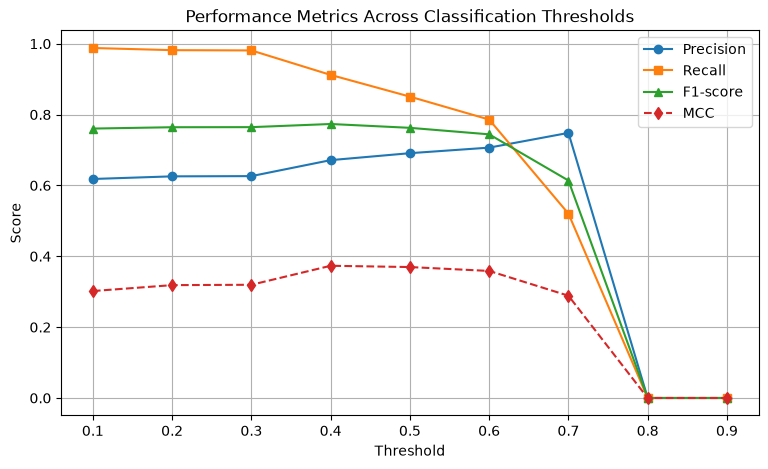

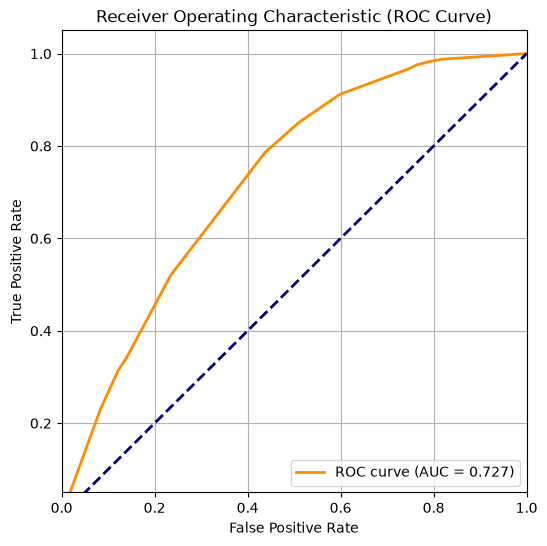

In [17]:
# Assignment: Part 3.4 - Threshold Sensitivity Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef, roc_curve, auc

# Get predicted probabilities for the positive class
y_prob = clf.predict_proba(X_test)[:, 1]

# Define thresholds to evaluate
thresholds = np.arange(0.1, 1.0, 0.1)

metrics_results = []

for th in thresholds:
    # Apply threshold to probabilities
    y_pred_th = (y_prob >= th).astype(int)
    
    # Compute metrics (handle potential zero division warnings safely)
    prec = precision_score(y_test, y_pred_th, zero_division=0)
    rec = recall_score(y_test, y_pred_th, zero_division=0)
    f1 = f1_score(y_test, y_pred_th, zero_division=0)
    mcc = matthews_corrcoef(y_test, y_pred_th)
    
    metrics_results.append({
        'Threshold': th,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'MCC': mcc
    })

# Create metrics dataframe
metrics_df = pd.DataFrame(metrics_results)
print("--- Threshold Sensitivity Metrics ---")
display(metrics_df)

# Plot Metrics across Thresholds
plt.figure(figsize=(9, 5))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='s', label='Recall')
plt.plot(metrics_df['Threshold'], metrics_df['F1-score'], marker='^', label='F1-score')
plt.plot(metrics_df['Threshold'], metrics_df['MCC'], marker='d', label='MCC', linestyle='--')
plt.title('Performance Metrics Across Classification Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

# Plot ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC Curve)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

### Section 3.4: Threshold Sensitivity Analysis & Discussion

* **Performance Across Thresholds:**
  * **Low Thresholds (0.1 - 0.3):** Yield very high Recall (~0.98) but lower Precision, as the model over-predicts the positive class.
  * **Balanced Thresholds (0.4 - 0.6):** Provide the optimal operating region where $F_1$-score and MCC peak (around threshold 0.4-0.5), balancing False Positives and False Negatives.
  * **High Thresholds (0.8 - 0.9):** Cause performance to collapse to zero because the probabilities outputted by the classifier rarely exceed these extreme cutoffs.

* **ROC Curve & Trade-offs:**
  * The ROC curve and an **AUC of 0.727** demonstrate fair discriminative ability given the limited feature set.
  * **Operating Regions:** Stable performance is achieved in the mid-range thresholds (0.4-0.6), while extremes suffer from high instability due to class boundary constraints.

### Section 3.5: Comprehensive Discussion & Reflection

* **Model Strengths and Limitations:**
  * **Strengths:** Ensemble and tree-based classifiers effectively handle non-linear boundaries and capture broad demographic patterns in animal intake data.
  * **Limitations:** The models struggle with extreme subsets and overlapping feature spaces when relying on limited input features.

* **Key Failure Modes:**
  * High-confidence errors and misclassifications heavily concentrate at the boundaries of the feature distributions (e.g., extreme ages or rare sub-populations) where classes overlap significantly.

* **Model Assumptions vs. Performance:**
  * Algorithms assuming linear boundaries or straightforward separability fail to capture complex categorical interactions, resulting in plateaued performance metrics (e.g., AUC of ~0.727).

* **Most Significant Insights:**
  * Error and threshold analyses reveal that algorithmic tuning cannot fully compensate for a lack of discriminative, high-quality features. 

* **Recommendations for Future Work:**
  * Enrich the feature space by incorporating diverse categorical attributes (such as specific breed groups, physical characteristics, and intake conditions).
  * Apply advanced handling techniques for class imbalance and outlier reduction to improve generalization and robustness.

## 4. Final Reflection

1. **Where does the model fail most?**
   * The models fail primarily at the boundaries of feature distributions (e.g., extreme age values and sparse sub-populations) and in regions where class categories or regression targets heavily overlap.

2. **Are failures due to data, model, or formulation?**
   * Failures stem predominantly from **data limitations** (lack of rich, highly-predictive features) coupled with **formulation constraints** (relying on basic feature sets), rather than purely algorithmic flaws.

3. **What improvements would you propose?**
   * Enriching the dataset with comprehensive categorical and numerical features (such as breed groups, physical traits, and intake conditions).
   * Implementing advanced feature engineering, handling class imbalances, and exploring gradient-boosting algorithms (like XGBoost or LightGBM).

4. **What insights did you gain in your analysis?**
   * Algorithmic complexity and hyper-parameter tuning cannot fully compensate for a lack of informative features. Comprehensive error, residual, and threshold analyses are essential for uncovering the true operational limits of predictive models beyond standard summary metrics.